# 1 EDA Operations

In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display 

In [2]:
df = pd.read_pickle("data/staySpain_transformed.pkl")

In [3]:
df_operations = df.copy()

In [4]:
df_operations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9650 entries, 0 to 9999
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   apartment_id                 9650 non-null   int64         
 1   name                         9650 non-null   object        
 2   description                  9650 non-null   object        
 3   host_id                      9650 non-null   int64         
 4   neighbourhood_name           9650 non-null   object        
 5   neighbourhood_district       9650 non-null   object        
 6   room_type                    9650 non-null   object        
 7   accommodates                 9650 non-null   int64         
 8   bathrooms                    9576 non-null   Int64         
 9   bedrooms                     9581 non-null   Int64         
 10  beds                         9605 non-null   Int64         
 11  amenities_list               9634 non-null   obj

In [5]:
df_operations.describe()

,apartment_id,host_id,accommodates,bathrooms,bedrooms,beds,price,pricexperson,minimum_nights,maximum_nights,...,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,general_satisf,reviews_per_month,insert_date,amenities_score
count,9.650000e+03,9.650000e+03,9650.000000,9576.0,9581.0,9605.0,9650.000000,9650.000000,9650.000000,9650.000000,...,7017.000000,7017.000000,7017.000000,7017.000000,7017.000000,7017.000000,7017.000000,7120.000000,9650,9650.000000
mean,2.122473e+07,9.096714e+07,4.267047,1.593567,1.93675,2.922124,1035.775373,261.521630,4.969948,758.793575,...,9.445490,9.310817,9.620921,9.618925,9.539404,9.134958,9.507111,123.525140,2019-07-22 16:33:04.663212544,44.838342
min,1.196400e+04,1.070400e+04,1.000000,0.0,0.0,0.0,60.000000,9.090909,1.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2017-01-04 00:00:00,0.000000
25%,1.332096e+07,1.506455e+07,2.000000,1.0,1.0,1.0,450.000000,150.000000,1.000000,60.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.200000,18.000000,2018-11-07 00:00:00,32.000000
50%,2.065612e+07,6.569780e+07,4.000000,1.0,2.0,2.0,750.000000,208.000000,2.000000,1125.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,9.800000,58.000000,2019-08-31 00:00:00,44.000000
75%,3.016933e+07,1.429782e+08,6.000000,2.0,3.0,4.0,1250.000000,300.000000,4.000000,1125.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,177.000000,2020-05-11 00:00:00,57.000000
max,4.806155e+07,3.874783e+08,29.000000,13.0,50.0,30.0,28571.000000,12643.000000,1125.000000,1125.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1273.000000,2021-02-27 00:00:00,99.000000
std,1.161793e+07,8.717483e+07,2.588807,0.990406,1.375512,2.268378,983.394042,261.865544,17.986676,498.813539,...,0.960998,1.012684,0.838060,0.840214,0.784811,1.006620,0.681911,152.729857,NaN,17.165378


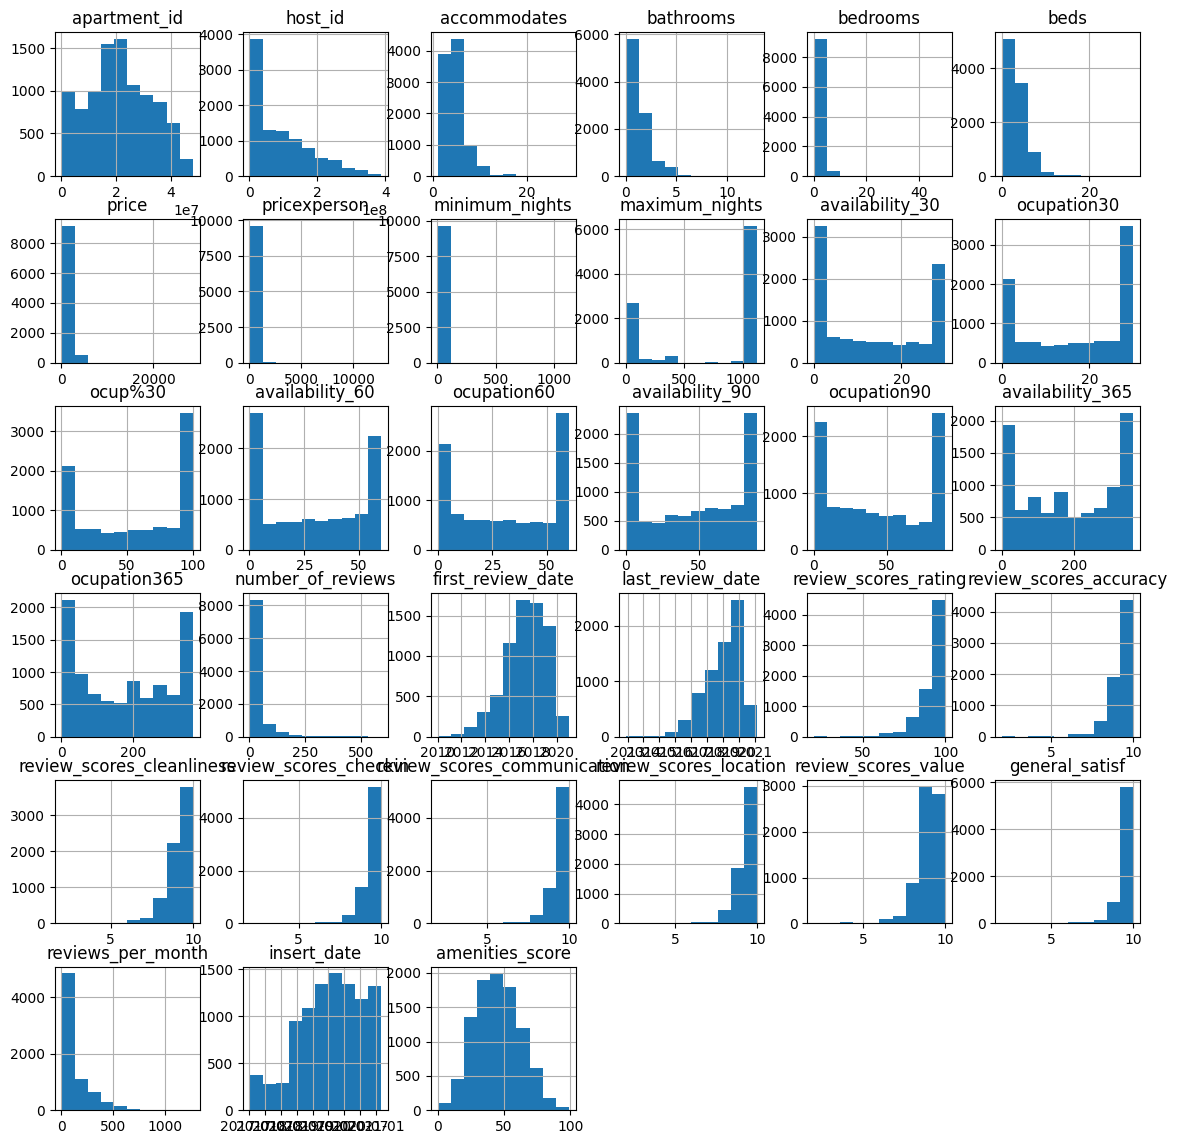

In [6]:
df_operations.hist(figsize=(14,14))
plt.show()

Com afecta el nombre d'habitacions, banys i llits 
disponibles a la disponibilitat mitjana dels allotjaments? Difereix entre ciutats? 

In [12]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# ----------------- CONFIG -----------------
BASE_DF = df_operations.copy()
FEATURES = ['bedrooms','bathrooms','beds']
CANDIDATE_CITY_COLS = [
    'city','market','municipality','neighbourhood_cleansed','neighborhood','neighbourhood'
]

# ----------------- 1) Detect city -----------------
city_col = next((c for c in CANDIDATE_CITY_COLS if c in BASE_DF.columns), None)

# ----------------- 2) Helper: preparar dataset para una ventana dada -----------------
def prepare_for_window(df_raw, target_col, window_label):
    if target_col not in df_raw.columns:
        return None  # no existe esa ventana en el dataset

    df = df_raw.copy()

    # Mantener solo lo necesario
    cols_needed = FEATURES + [target_col] + ([city_col] if city_col else [])
    missing_feats = [c for c in FEATURES if c not in df.columns]
    if missing_feats:
        raise ValueError(f"Faltan columnas requeridas: {missing_feats}")

    df = df[cols_needed]

    # Numerizar y sanear negativos
    for c in FEATURES + [target_col]:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        df.loc[df[c] < 0, c] = np.nan

    print(f"\n[Window {window_label}] Missing BEFORE:")
    print(df[FEATURES + [target_col]].isna().sum().sort_values(ascending=False))

    # Imputar solo predictoras (mediana por ciudad si existe; si no, global)
    if city_col:
        for c in FEATURES:
            df[c] = df.groupby(city_col)[c].transform(lambda s: s.fillna(s.median()))
    else:
        imputer = SimpleImputer(strategy='median')
        df[FEATURES] = imputer.fit_transform(df[FEATURES])

    # No imputamos el target; se eliminan filas sin target (y sin city si es necesario)
    drop_subset = [target_col] + ([city_col] if city_col else [])
    df = df.dropna(subset=drop_subset)

    # Unificar a escala mensual -> availability_avg_month
    if target_col == 'availability_365':
        df['availability_avg_month'] = df[target_col] / 12.0
    elif target_col in ['availability_30', 'availability_60', 'availability_90']:
        # Escalamos a ~30 días
        if target_col == 'availability_30':
            df['availability_avg_month'] = df[target_col]  # ya es mensual
        else:
            denom = int(target_col.split('_')[-1])  # 60 o 90
            df['availability_avg_month'] = df[target_col] / (denom / 30)
    else:
        # Si es otro nombre genérico, asumimos que está en días/año y convertimos a mes
        df['availability_avg_month'] = df[target_col] / 12.0

    print(f"[Window {window_label}] Missing AFTER (predictors):")
    print(df[FEATURES].isna().sum().sort_values(ascending=False))
    print(f"[Window {window_label}] Final shape: {df.shape}")

    # Etiqueta de ventana y orden de columnas
    df['window'] = str(window_label)
    ordered_cols = FEATURES + ([city_col] if city_col else []) + ['availability_avg_month','window']
    return df[ordered_cols]

# ----------------- 3) Construir datasets por ventana -----------------
df_w365 = prepare_for_window(BASE_DF, 'availability_365', 365)
df_w30  = prepare_for_window(BASE_DF, 'availability_30', 30)

# ----------------- 4) Unificar en un solo dataframe final -----------------
if (df_w365 is None) and (df_w30 is None):
    raise ValueError("No se encontraron columnas de disponibilidad ni para 365 ni para 30 días.")
elif (df_w365 is not None) and (df_w30 is not None):
    # Alineamos columnas y concatenamos
    common_cols = set(df_w365.columns).intersection(set(df_w30.columns))
    df_ready = pd.concat([df_w365[list(common_cols)], df_w30[list(common_cols)]], ignore_index=True)
elif df_w365 is not None:
    df_ready = df_w365.copy()
else:
    df_ready = df_w30.copy()

print("\n✅ df_ready creado. Ventanas incluidas:", df_ready['window'].unique().tolist())
print("Preview:")
df_ready.head()



[Window 365] Missing BEFORE:
bathrooms           74
bedrooms            69
beds                45
availability_365     0
dtype: int64
[Window 365] Missing AFTER (predictors):
bedrooms     0
bathrooms    0
beds         0
dtype: int64
[Window 365] Final shape: (9650, 6)

[Window 30] Missing BEFORE:
bathrooms          74
bedrooms           69
beds               45
availability_30     0
dtype: int64
[Window 30] Missing AFTER (predictors):
bedrooms     0
bathrooms    0
beds         0
dtype: int64
[Window 30] Final shape: (9650, 6)

✅ df_ready creado. Ventanas incluidas: ['365', '30']
Preview:


,beds,bedrooms,city,bathrooms,window,availability_avg_month
0,1,1,Malaga,2,365,10.833333
1,1,1,Madrid,1,365,13.500000
2,2,2,Sevilla,1,365,22.500000
3,1,1,Barcelona,2,365,25.000000
4,5,2,Girona,1,365,26.000000


regresion linal

In [14]:
import statsmodels.api as sm
import pandas as pd

df_365 = df_ready[df_ready['window'] == '365'].copy()
df_30 = df_ready[df_ready['window'] == '30'].copy()

def run_regression(df, label):
    print(f"\n📊 Modelo de regresión lineal para ventana de {label} días:\n")

    # Variables predictoras y objetivo
    X = df[['bedrooms', 'bathrooms', 'beds']].astype(float)
    y = df['availability_avg_month'].astype(float)

    # Agregar constante (intercepto)
    X = sm.add_constant(X)

    # Comprobación final
    assert not X.isna().any().any(), "❌ X tiene valores NaN"
    assert not y.isna().any(), "❌ y tiene valores NaN"

    # Ajustar modelo
    model = sm.OLS(y, X).fit()

    # Mostrar resumen completo
    print(model.summary())

    return model

model_365 = run_regression(df_365, 365)
model_30 = run_regression(df_30, 30)



📊 Modelo de regresión lineal para ventana de 365 días:

                              OLS Regression Results                              
Dep. Variable:     availability_avg_month   R-squared:                       0.016
Model:                                OLS   Adj. R-squared:                  0.015
Method:                     Least Squares   F-statistic:                     51.10
Date:                    Tue, 07 Oct 2025   Prob (F-statistic):           9.34e-33
Time:                            17:08:12   Log-Likelihood:                -36678.
No. Observations:                    9650   AIC:                         7.336e+04
Df Residuals:                        9646   BIC:                         7.339e+04
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

In [15]:
import statsmodels.formula.api as smf

# Filtramos por una sola ventana, por ejemplo: 365
df_model = df_ready[df_ready['window'] == '365'].copy()

# Ajustamos el modelo con interacción entre camas y ciudad
model_interact = smf.ols(
    formula="availability_avg_month ~ bedrooms + bathrooms + beds * C(city)", 
    data=df_model
).fit()

# Mostrar resumen del modelo
print(model_interact.summary())


                              OLS Regression Results                              
Dep. Variable:     availability_avg_month   R-squared:                       0.032
Model:                                OLS   Adj. R-squared:                  0.030
Method:                     Least Squares   F-statistic:                     18.50
Date:                    Tue, 07 Oct 2025   Prob (F-statistic):           1.11e-55
Time:                            17:13:40   Log-Likelihood:                -36599.
No. Observations:                    9650   AIC:                         7.323e+04
Df Residuals:                        9632   BIC:                         7.336e+04
Df Model:                              17                                         
Covariance Type:                nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------